In [48]:
from src.utils import read_obs
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
obs = read_obs("/root/capsule/data/adata/CaH_filtered_nuclei.2026-05-11.h5ad")

In [28]:
obs

,Neurotypical reference,Donor ID,Organism,Brain Region,Sex,Gender,Age at Death,Race (choice=White),Race (choice=Black/ African American),Race (choice=Asian),...,number of AT8 positive cells per area,percent AT8 positive area,percent pTDP43 positive area,percent 6e10 dense core plaque area,percent 6e10 positive area,percent of 6e10 positive objects colocalized with Iba1 positive objects,tangle_per_tissue_area_um^2,CPS,CPS_AT8,CPS_6E10
exp_component_name,,,,,,,,,,,,,,,,,,,,,
AAACCCAAGAATCTAG-L8HX_220714_02_B02-1194262311,False,H21.33.004,human,Human CaH,Male,Male,93.0,Checked,Unchecked,Unchecked,...,2.610000e-08,0.000208,0.000132,0.004326,0.0,0.0,7.734864e-08,0.190431,0.192286,0.149080
AAACCCAAGCACAAAT-L8HX_220714_02_B02-1194262311,False,H21.33.004,human,Human CaH,Male,Male,93.0,Checked,Unchecked,Unchecked,...,2.610000e-08,0.000208,0.000132,0.004326,0.0,0.0,7.734864e-08,0.190431,0.192286,0.149080
AAACCCACAATTTCCT-L8HX_220714_02_B02-1194262311,False,H21.33.004,human,Human CaH,Male,Male,93.0,Checked,Unchecked,Unchecked,...,2.610000e-08,0.000208,0.000132,0.004326,0.0,0.0,7.734864e-08,0.190431,0.192286,0.149080
AAACCCACAGCAATTC-L8HX_220714_02_B02-1194262311,False,H21.33.004,human,Human CaH,Male,Male,93.0,Checked,Unchecked,Unchecked,...,2.610000e-08,0.000208,0.000132,0.004326,0.0,0.0,7.734864e-08,0.190431,0.192286,0.149080
AAACCCACAGGTGTTT-L8HX_220714_02_B02-1194262311,False,H21.33.004,human,Human CaH,Male,Male,93.0,Checked,Unchecked,Unchecked,...,2.610000e-08,0.000208,0.000132,0.004326,0.0,0.0,7.734864e-08,0.190431,0.192286,0.149080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCTAATCTC-L8XR_221201_02_A01-1233285482,False,H21.33.001,human,Human CaH,Male,Male,80.0,Checked,Unchecked,Unchecked,...,1.450000e-07,0.007741,0.000322,0.000000,0.0,0.0,3.301860e-07,0.433192,0.450192,0.293591
TTTGTGTTCTTTGAGA-L8XR_221201_02_A01-1233285482,False,H21.33.001,human,Human CaH,Male,Male,80.0,Checked,Unchecked,Unchecked,...,1.450000e-07,0.007741,0.000322,0.000000,0.0,0.0,3.301860e-07,0.433192,0.450192,0.293591
TTTGTTGGTAACAGGG-L8XR_221201_02_A01-1233285482,False,H21.33.001,human,Human CaH,Male,Male,80.0,Checked,Unchecked,Unchecked,...,1.450000e-07,0.007741,0.000322,0.000000,0.0,0.0,3.301860e-07,0.433192,0.450192,0.293591


In [62]:
obs_donor_path = (obs
.groupby("Donor ID")[["Braak", "Thal", "Overall AD neuropathological Change", "CPS", "CPS_6E10", "CPS_AT8", "percent AT8 positive area", "percent 6e10 positive area"]]
.first()
.rename(columns = {"Overall AD neuropathological Change":"ADNC", "percent 6e10 positive area":"6E10", "percent AT8 positive area":"AT8", "CPS_AT8":"$CPS_{AT8}$", "CPS_6E10":"$CPS_{6E10}$"})
)

/tmp/ipykernel_13641/294551108.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Donor ID")[["Braak", "Thal", "Overall AD neuropathological Change", "CPS", "CPS_6E10", "CPS_AT8", "percent AT8 positive area", "percent 6e10 positive area"]]


In [63]:
for col in ["Braak", "Thal", "ADNC"]:
    if obs_donor_path[col].dtype == "category":
        obs_donor_path[col] = obs_donor_path[col].cat.codes.astype(int)

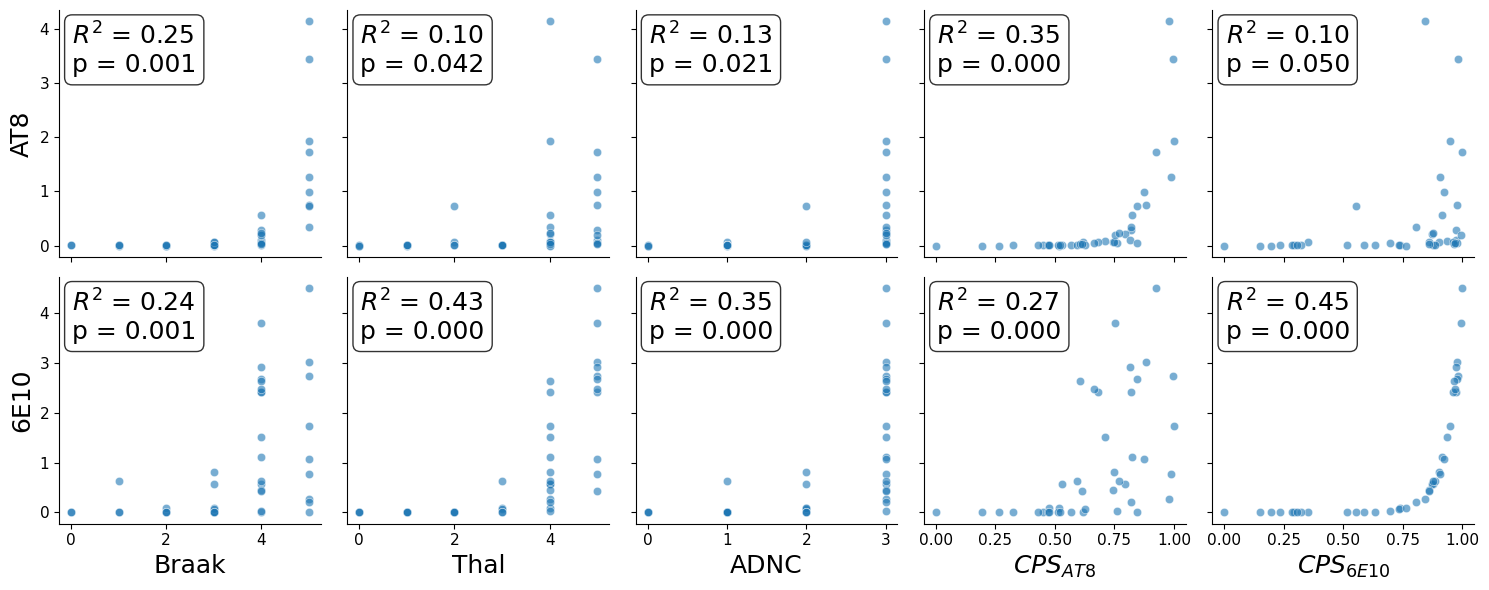

In [64]:
from scipy.stats import pearsonr

x_vars = ["AT8", "6E10"]
y_vars = ["Braak", "Thal", "ADNC","$CPS_{AT8}$","$CPS_{6E10}$"]

g = sns.PairGrid(obs_donor_path, x_vars=y_vars, y_vars=x_vars, height=3, )
g.map(sns.scatterplot, alpha=0.6,)

def annotate_corr(x, y, **kwargs):
    # drop rows where either value is missing
    mask = x.notna() & y.notna()
    r, p = pearsonr(x[mask], y[mask])
    ax = plt.gca()
    ax.annotate(f'$R^2$ = {r**2:.2f}\np = {p:.3f}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=18,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

g.map(annotate_corr)
for ax in g.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=18)
    ax.set_ylabel(ax.get_ylabel(), fontsize=18)
    ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()